# 第 14 章：用 Random Forest 預測顧客是否購買

適合已了解 `X`、`y`、訓練集與測試集，第一次學習樹模型的讀者。

## 學習目標

- 用生活化方式理解決策樹與 Random Forest。
- 建立二元分類模型並讀懂購買機率。
- 使用混淆矩陣、precision、recall 評估模型。
- 用訓練／測試差距辨認過度擬合。
- 解讀特徵重要性，並了解其限制。


## 學習流程

1. 認識樹與森林
2. 準備分類資料
3. 建立第一座森林
4. 評估分類結果
5. 檢查過度擬合
6. 解讀特徵重要性
7. 預測新案例與動手練習


## 1. Random Forest 是什麼？

一棵決策樹會連續問問題，例如：

```text
有加入購物車嗎？
├─ 有 → 瀏覽頁數多嗎？ → 預測購買／未購買
└─ 無 → 進站時間為晚上嗎？ → 預測購買／未購買
```

單棵樹可能太相信訓練資料。Random Forest 會建立許多略有不同的樹，再讓它們共同投票。就像詢問一群判斷方式不同的人，結果通常比只問一人穩定。

本章仍預測：`target = 1` 有購買，`target = 0` 未購買。


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from common import build_features, load_data

RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)


## 2. 載入並準備資料

沿用四個容易理解的數值特徵，讓注意力集中在模型概念：

- `page_view`：瀏覽頁數
- `add_to_cart`：加入購物車次數
- `session_hour`：進站小時
- `is_weekend`：是否為週末

> `purchase` 直接揭露答案，絕對不能當成預測特徵。


In [2]:
data = load_data()
model_df = build_features(data)
feature_names = ["page_view", "add_to_cart", "session_hour", "is_weekend"]
model_df = model_df[feature_names + ["target"]].dropna().copy()
X = model_df[feature_names]
y = model_df["target"]
print(f"模型資料：{len(model_df):,} 筆")
print(f"購買率：{y.mean():.1%}")
display(model_df.head())


模型資料：70,000 筆
購買率：12.4%


,page_view,add_to_cart,session_hour,is_weekend,target
0,2,0,11,0,0
1,5,1,11,0,0
2,3,0,16,0,0
3,2,0,16,0,0
4,3,0,8,1,0


## 3. 分割訓練集與測試集

訓練集用來學習，測試集只用來模擬面對未見資料的表現。Random Forest 不要求特徵標準化，所以這次不需要 `StandardScaler`。


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
split_summary = pd.DataFrame({
    "資料集": ["訓練集", "測試集"],
    "筆數": [len(X_train), len(X_test)],
    "購買率": [y_train.mean(), y_test.mean()],
})
display(split_summary.style.format({"購買率": "{:.1%}"}))


,資料集,筆數,購買率
0,訓練集,52500,12.4%
1,測試集,17500,12.4%


## 4. 建立第一座森林

先使用一組容易理解且不會讓樹無限制生長的設定：

- `n_estimators=100`：建立 100 棵樹。
- `max_depth=6`：每棵樹最多 6 層。
- `min_samples_leaf=20`：每個最終葉節點至少 20 筆資料。
- `class_weight="balanced"`：讓模型更重視較少的購買案例。

限制樹的複雜度有助於降低過度擬合。


In [4]:
forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",#處理購買者較少的問題
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
forest.fit(X_train, y_train)
print(f"森林共有 {len(forest.estimators_)} 棵樹")


森林共有 100 棵樹


## 5. 從投票得到購買機率

`predict_proba()` 提供模型估計的購買機率；`predict()` 預設以 0.5 為門檻轉為類別。Random Forest 的機率可視為森林投票的綜合結果，但不代表保證。


In [5]:
test_probability = forest.predict_proba(X_test)[:, 1]
test_prediction = forest.predict(X_test)
preview = X_test.head(10).copy()
preview["實際答案"] = y_test.head(10)
preview["購買機率"] = test_probability[:10]
preview["模型預測"] = test_prediction[:10]
display(preview.style.format({"購買機率": "{:.1%}"}))


,page_view,add_to_cart,session_hour,is_weekend,實際答案,購買機率,模型預測
69516,1,0,15,0,0,42.4%,0
25239,5,1,8,0,0,73.1%,1
17284,5,0,7,0,0,41.8%,0
51080,3,0,21,0,0,43.8%,0
26670,2,0,9,0,0,45.1%,0
50654,2,0,15,1,0,44.1%,0
30540,4,0,7,1,0,40.0%,0
16195,1,0,21,0,0,44.7%,0
56574,3,0,12,0,1,43.6%,0
55107,3,0,10,0,0,43.9%,0


## 6. 評估分類結果

購買者比例較低，因此不能只看 accuracy。

- **precision**：預測購買者中，實際購買的比例。
- **recall**：實際購買者中，被模型找到的比例。
- **F1-score**：precision 與 recall 的綜合分數。


In [6]:
forest_accuracy = accuracy_score(y_test, test_prediction)
always_zero_accuracy = accuracy_score(y_test, [0] * len(y_test))
print(f"Random Forest accuracy：{forest_accuracy:.1%}")
print(f"全部猜未購買的 accuracy：{always_zero_accuracy:.1%}")
print("\n分類報告：")
print(classification_report(y_test, test_prediction, target_names=["未購買", "購買"], digits=3, zero_division=0))


Random Forest accuracy：77.8%
全部猜未購買的 accuracy：87.6%

分類報告：
              precision    recall  f1-score   support

         未購買      0.907     0.831     0.868     15337
          購買      0.250     0.399     0.307      2163

    accuracy                          0.778     17500
   macro avg      0.579     0.615     0.588     17500
weighted avg      0.826     0.778     0.798     17500



### 混淆矩陣：模型猜對與猜錯多少人？

左上、右下是正確預測；另外兩格是錯誤預測。評估模型時要把錯誤人數與商業成本一起考慮。


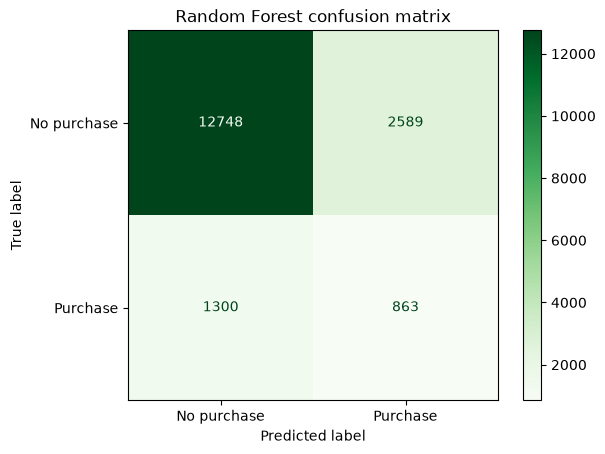

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test, test_prediction, display_labels=["No purchase", "Purchase"], cmap="Greens"
)
plt.title("Random Forest confusion matrix")
plt.show()


## 7. 模型是否背答案？

**過度擬合**是模型太熟悉訓練資料，卻無法處理新資料。比較訓練集與測試集分數是第一個簡單警報：訓練分數高很多時要特別留意。


In [8]:
train_prediction = forest.predict(X_train)
score_comparison = pd.DataFrame({
    "資料集": ["訓練集", "測試集"],
    "accuracy": [accuracy_score(y_train, train_prediction), accuracy_score(y_test, test_prediction)],
})
score_comparison["與訓練集差距"] = score_comparison["accuracy"].iloc[0] - score_comparison["accuracy"]
display(score_comparison.style.format({"accuracy": "{:.1%}", "與訓練集差距": "{:.1%}"}))


,資料集,accuracy,與訓練集差距
0,訓練集,77.8%,0.0%
1,測試集,77.8%,-0.0%


## 8. 哪些特徵比較重要？

`feature_importances_` 顯示模型切分時使用各特徵的相對程度，總和為 1。重要性高表示模型常靠它做出有效切分，**不表示因果關係，也不表示提高該數值就一定促成購買**。


,特徵,重要性
1,add_to_cart,88.4%
2,session_hour,8.6%
0,page_view,2.4%
3,is_weekend,0.6%


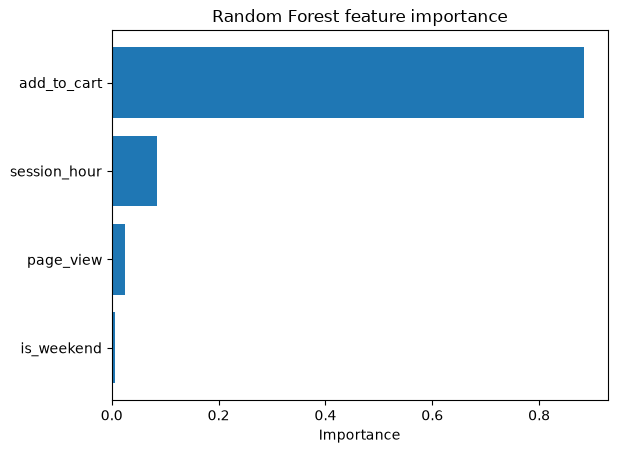

In [9]:
importance = pd.DataFrame({
    "特徵": feature_names,
    "重要性": forest.feature_importances_,
}).sort_values("重要性", ascending=False)
display(importance.style.format({"重要性": "{:.1%}"}))

plt.barh(importance["特徵"][::-1], importance["重要性"][::-1])
plt.xlabel("Importance")
plt.title("Random Forest feature importance")
plt.show()


## 9. 預測新的工作階段

新資料必須與訓練資料使用相同欄位。先完成預測，再加入顯示用欄位，避免把額外欄位送進模型。


In [10]:
new_sessions = pd.DataFrame([
    {"page_view": 1, "add_to_cart": 0, "session_hour": 10, "is_weekend": 0},
    {"page_view": 5, "add_to_cart": 1, "session_hour": 20, "is_weekend": 1},
])
new_probability = forest.predict_proba(new_sessions)[:, 1]
new_prediction = forest.predict(new_sessions)
new_sessions["購買機率"] = new_probability
new_sessions["預測類別"] = new_prediction
display(new_sessions.style.format({"購買機率": "{:.1%}"}))


,page_view,add_to_cart,session_hour,is_weekend,購買機率,預測類別
0,1,0,10,0,40.3%,0
1,5,1,20,1,70.3%,1


## 10. 動手練習：如果不限制樹深度？

建立另一個不設定 `max_depth` 的模型。執行前先預測：訓練 accuracy、測試 accuracy，以及兩者差距會如何變化？


In [11]:
# 參考答案：可先遮住，再自行完成。
deep_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
deep_forest.fit(X_train, y_train)
deep_train_accuracy = accuracy_score(y_train, deep_forest.predict(X_train))
deep_test_accuracy = accuracy_score(y_test, deep_forest.predict(X_test))

exercise_result = pd.DataFrame({
    "模型": ["受限制森林", "不限制深度森林"],
    "訓練 accuracy": [accuracy_score(y_train, train_prediction), deep_train_accuracy],
    "測試 accuracy": [forest_accuracy, deep_test_accuracy],
})
exercise_result["訓練－測試差距"] = exercise_result["訓練 accuracy"] - exercise_result["測試 accuracy"]
display(exercise_result.style.format({col: "{:.1%}" for col in exercise_result.columns if col != "模型"}))


,模型,訓練 accuracy,測試 accuracy,訓練－測試差距
0,受限制森林,77.8%,77.8%,-0.0%
1,不限制深度森林,73.4%,72.3%,1.1%


### 練習解讀

更深的樹通常更能貼合訓練資料，但不保證測試表現更好。若訓練／測試差距擴大，就是過度擬合警訊。可透過 `max_depth`、`min_samples_leaf` 或交叉驗證控制複雜度。

## 常見錯誤與重點整理

- 不可把 `purchase` 等答案欄位放進特徵。
- 不可因訓練分數很高就宣稱模型很好。
- 類別不平衡時不可只看 accuracy。
- 特徵重要性不是因果效果。
- Random Forest 是多棵不同決策樹的集體判斷。
- 樹模型通常不需標準化，但仍需處理缺失值與類別欄位。
- 下一步可用交叉驗證與 GridSearchCV 系統化選擇參數。
